# Real-data experiment with Meteostat (step by step)

This notebook reproduces the real-data workflow in four stages:
1. Inspect the full Meteostat dataset visually.
2. Build three periods and station-wise pairwise differences.
3. Plot the period differences.
4. Run RKBT on each pairwise-difference dataset and show results.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rkbt import (
    RKBTConfig,
    SampleCovEstimator,
    fit_rkbt,
    simultaneous_credible_band,
    compute_rope,
)
from experiments import load_real_dataset

SEED = 2026
rng = np.random.default_rng(SEED)

In [2]:
grid, cases = load_real_dataset(
    "real_weather",
    smoothing=False,
    load_from_file=True,
)
periods = [case[0] for case in cases]

# 2) Generate three periods by months and station-wise pairwise differences
# Each period curve already has shape (n_stations, 12): mean daily temp across months in that period.

period_1, period_2, period_3 = periods

datasets = {
    "2000s - 1990s": period_1,
    "2010s - 2000s": period_3,
    "2010s - 1990s": period_2,
}

for name, arr in datasets.items():
    print(f"{name}: shape={arr.shape}, mean shift={arr.mean():.3f} °C")

2000s - 1990s: shape=(24, 12), mean shift=0.008 °C
2010s - 2000s: shape=(24, 12), mean shift=0.275 °C
2010s - 1990s: shape=(24, 12), mean shift=0.282 °C


In [3]:
# 4) Run RKBT and show results
if not datasets:
    print("No pairwise datasets available. Load year-resolved data first.")
else:
    rkbt_cfg = RKBTConfig(
        pi0=1./3,
        eta_scaling_factor=0.25,
        lambda_p=None,
        nwalkers=64,
        ntemps=5,
        nsteps=1000,
        nburn=1500,
        nleaves_min=1,
        nleaves_max=12,
        seed=SEED,
    )

    cov_estimator = SampleCovEstimator()

    rows = []
    mu_pm_lst = []
    cbands_lst = []
    X_lst = []
    names_lst = []
    for name, X in datasets.items():
        X_lst.append(X)
        names_lst.append(name)
        K_hat = cov_estimator.estimate(X)

        fit = fit_rkbt(
            X,
            K_hat,
            grid,
            config=rkbt_cfg,
            progress=True,
        )

        summary = fit.summary

        draws = fit.draw_posterior(ndraws_extra=10, rng=rng)
        mu_draws = draws['mu_draws']
        mu_pm = summary.posterior_mean_mu

        epsilon = 0.1
        rope_epsilon = compute_rope(mu_draws, epsilon)
        print(f"ROPE [{epsilon}]:", round(rope_epsilon, 3))

        lower_band, upper_band, c95 = simultaneous_credible_band(mu_draws, mu_pm, alpha=0.05)

        cbands_lst.append((lower_band, upper_band, c95))
        mu_pm_lst.append(mu_pm)

        rows.append(
            {
                "experiment": name,
                "posterior_null_prob": summary.posterior_null_prob,
                "log_bf10": summary.log_bf10,
                "E[p|X]": summary.p_samples.mean(),
                "ROPE(0.1)": rope_epsilon,
                "reject_bf10_gt_3": bool(summary.log_bf10 > np.log(3.0)),
            }
        )

    results_df = pd.DataFrame(rows)
    display(results_df)

100%|██████████| 1000/1000 [00:31<00:00, 31.57it/s]


ROPE [0.1]: 0.421


100%|██████████| 1000/1000 [00:34<00:00, 29.23it/s]


ROPE [0.1]: 0.212


100%|██████████| 1000/1000 [00:33<00:00, 29.63it/s]


ROPE [0.1]: 0.098


,experiment,posterior_null_prob,log_bf10,E[p|X],ROPE(0.1),reject_bf10_gt_3
0,2000s - 1990s,0.330212,0.014080,4.680719,0.420520,False
1,2010s - 2000s,0.063525,1.997544,5.230922,0.211514,True
2,2010s - 1990s,0.078351,1.771814,4.883234,0.098254,True


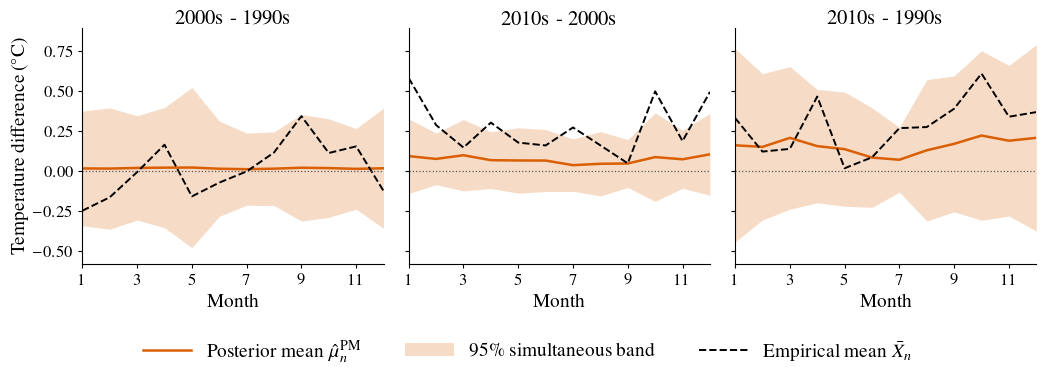

In [4]:
# ...existing code...
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

FONTSIZE = 14
FONTSIZE_SMALL = FONTSIZE - 2
FONTSIZE_LARGE = FONTSIZE + 1

aos_rcparams = {
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["TeX Gyre Termes", "Times New Roman", "Nimbus Roman No9 L", "DejaVu Serif"],
    "text.latex.preamble": r"\usepackage{newtxtext,newtxmath}",
    "font.size": FONTSIZE,
    "axes.labelsize": FONTSIZE,
    "axes.titlesize": FONTSIZE_LARGE,
    "xtick.labelsize": FONTSIZE_SMALL,
    "ytick.labelsize": FONTSIZE_SMALL,
    "legend.fontsize": FONTSIZE,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.7,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "axes.unicode_minus": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
}

plt.rcdefaults()
with plt.rc_context(aos_rcparams):

    fig, axes = plt.subplots(1, 3, figsize=(10.6, 3.9), sharex=True, sharey=True)
    plot_items = list(zip(names_lst, X_lst, cbands_lst, mu_pm_lst))


    # Common y-scale across all panels
    all_vals = []
    for _, X, (lower_band, upper_band, _), mu_pm in plot_items:
        all_vals.extend([lower_band, upper_band, mu_pm, np.mean(X, axis=0)])
    all_vals = np.concatenate([np.asarray(v).ravel() for v in all_vals])
    ymin, ymax = np.min(all_vals), np.max(all_vals)
    ypad = 0.08 * (ymax - ymin + 1e-12)

    band_color = "#d95f02"
    band_alpha = 0.22

    for ax, (name, X, (lower_band, upper_band, _), mu_pm) in zip(
        axes, plot_items
    ):
        x_axis = np.arange(1, X.shape[1] + 1)

        ax.fill_between(
            x_axis,
            lower_band,
            upper_band,
            color=band_color,
            alpha=band_alpha,
            linewidth=0,
        )
        ax.plot(x_axis, mu_pm, color=band_color, lw=1.8)
        ax.plot(x_axis, np.mean(X, axis=0), color="black", ls="--", lw=1.4)
        ax.axhline(0.0, color="0.35", ls=":", lw=0.9)

        ax.set_title(name, pad=2)
        ax.set_xlim(1, 12)
        ax.set_xticks(np.arange(1, 13, 2))
        ax.set_ylim(ymin - ypad, ymax + ypad)
        ax.grid(False)
        ax.tick_params(length=3)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_xlabel("Month")

    axes[0].set_ylabel(r"Temperature difference ($^\circ$C)",)

    #fig.supxlabel("Month", y=0.125, fontsize=FONTSIZE)

    legend_handles = [
        Line2D([0], [0], color=band_color, lw=1.8, label=r"Posterior mean $\hat\mu_n^{\mathrm{PM}}$"),
        Patch(facecolor=band_color, edgecolor="none", alpha=band_alpha, label="95\\% simultaneous band"),
        Line2D([0], [0], color="black", ls="--", lw=1.4, label=r"Empirical mean $\bar{X}_n$"),
    ]

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 0),
        handlelength=2.5,
        columnspacing=2.3,
    )

    fig.tight_layout(rect=(0, 0.12, 1, 1))
    fig.savefig("real_climate_posterior.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)
    # ...existing code...